In [57]:
import pandas as pd
import numpy as np
from keras import layers, models
import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [58]:
data = pd.read_csv("untrack/HousingData.csv")

In [59]:
"""
    Variables in order:
    CRIM     per capita crime rate by town
    ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
    INDUS    proportion of non-retail business acres per town
    CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
    NOX      nitric oxides concentration (parts per 10 million)
    RM       average number of rooms per dwelling
    AGE      proportion of owner-occupied units built prior to 1940
    DIS      weighted distances to five Boston employment centres
    RAD      index of accessibility to radial highways
    TAX      full-value property-tax rate per $10,000
    PTRATIO  pupil-teacher ratio by town
    B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
    LSTAT    % lower status of the population
    MEDV     Median value of owner-occupied homes in $1000's
"""

"\n    Variables in order:\n    CRIM     per capita crime rate by town\n    ZN       proportion of residential land zoned for lots over 25,000 sq.ft.\n    INDUS    proportion of non-retail business acres per town\n    CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)\n    NOX      nitric oxides concentration (parts per 10 million)\n    RM       average number of rooms per dwelling\n    AGE      proportion of owner-occupied units built prior to 1940\n    DIS      weighted distances to five Boston employment centres\n    RAD      index of accessibility to radial highways\n    TAX      full-value property-tax rate per $10,000\n    PTRATIO  pupil-teacher ratio by town\n    B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\n    LSTAT    % lower status of the population\n    MEDV     Median value of owner-occupied homes in $1000's\n"

In [60]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [61]:
X = data[["RM","AGE"]]
Y = data["MEDV"]

In [82]:
model = models.Sequential(
    [
        layers.Input(shape=(2,)),
        layers.Dense(32,activation="relu"),
        layers.Dense(1)
    ]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129 (516.00 B)

 Trainable params: 129 (516.00 B)

 Non-trainable params: 0 (0.00 B)

In [63]:
loss_fn = keras.losses.MeanSquaredError()

In [64]:
model.compile(
    optimizer="adam",
    loss=loss_fn,
    metrics=["mse"]
)

In [65]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2)

In [73]:
std = StandardScaler()
x_train = std.fit_transform(x_train)
x_test = std.transform(x_test)

In [80]:
model.fit(x_train, y_train, batch_size=32, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 583.2560 - mse: 583.2560 
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 582.6809 - mse: 582.6809 
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 582.1015 - mse: 582.1015 
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 581.5281 - mse: 581.5281 
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 580.9487 - mse: 580.9487 
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 580.3754 - mse: 580.3754 
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 579.8014 - mse: 579.8014 
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 579.2228 - mse: 579.2228 
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 578.6487 - mse: 578.6487 
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 578.0735 - mse: 578.0735 


In [79]:
model.evaluate(x_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 568.8258 - mse: 568.8258 


[568.8258056640625, 568.8258056640625]

In [75]:
y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [83]:
rm = np.linspace(X["RM"].min(), X["RM"].max(), 30)
age = np.linspace(X["AGE"].min(), X["AGE"].max(), 30)

RM, AGE = np.meshgrid(rm, age)

In [85]:
grid = np.c_[RM.ravel(), AGE.ravel()]

In [86]:
grid_scaled = std.transform(grid)

In [87]:
Z = model.predict(grid_scaled)
Z = Z.reshape(RM.shape)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


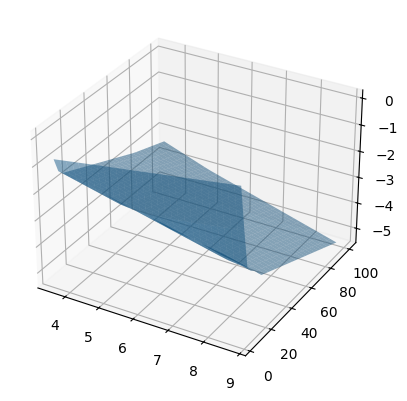

In [91]:
fig = plt.figure() 
ax = plt.axes(projection='3d')
ax.plot_surface(RM, AGE, Z, alpha=0.5)
plt.show()